In [4]:
%load_ext autoreload
%autoreload 2

from data_pipeline import *
import torch_geometric.transforms as T

from training_tools.splitter import StratifiedSplitterWithTestHoldout, HoldoutMode
from training_tools.task import TaskBinaryNodeClassification
from training_tools.trainer import Trainer
from training_tools.validation import CrossValidator
from training_tools.evaluation import Evaluator

from models import GCN, GCN_Sage, MLP

from tqdm import tqdm


pre_transform = T.Compose([
    MarkCommonNodes(edge_types=('AD','PD')),
    ReindexConsecutive(),
    MergeRelationsToHomogeneous(merge=['AD','PD'], edge_attr_reduce='sum'),
    FilterSmallConnectedComponents(topk=1)
])

ds = NeuroDegAnc2VecDataset(root='data', pre_transform=pre_transform, force_reload=True)
data = ds[0]

Processing...
Done!


In [6]:
def compare_models_over_repeats(
    data,                   # Data
    model_factories,           # [factory_A, factory_B, ...]
    splitter_ctor,             # lambda seed, mode: StratifiedNestedSplitter(...)
    task, trainer, mode="transductive",
    n = 10
):
    seeds=list(range(n, 2*n))
    # metriche per modello: dict[name] -> list of per-run test F1
    results = {i: [] for i in range(len(model_factories))}
    artifacts_list = []

    with tqdm(total=len(seeds), desc="Training Progress", unit="iteration") as pbar:
        for seed in seeds:
            splitter = splitter_ctor(seed, mode)
            parts = splitter.split(data, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

            for idx, factory in enumerate(model_factories):
                cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
                artifacts, summary = cv.run(task, data, parts)

                evaluator = Evaluator(model_factory=factory, mode=mode)
                test_metrics = evaluator.evaluate(task, data, parts, artifacts["best_state"])
                results[idx].append(test_metrics["f1"])  # metrica primaria
                artifacts_list.append(artifacts)
            pbar.update(1)

    return results, artifacts_list

model_factories = [
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0),
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0, head_type="mlp"),
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0.2),
    lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0),
    lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
]

splitter_ctor = lambda seed, mode: StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed, mode=mode)

task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=5)

results = dict()

# results['transductive'], artifacts_list = compare_models_over_repeats(data, model_factories, splitter_ctor, task, trainer, mode='transductive', n=200)

In [8]:
model_names = ["Sage2L", "Sage2L+MLP", "Sage2L+drop", "GCN", "MLP"]

len(artifacts_list)
model_artifacts = {
    "Sage2L" : artifacts_list[:50],
    "Sage2L+MLP" : artifacts_list[50:100],
    "Sage2L+drop" : artifacts_list[100:150],
    "GCN" : artifacts_list[150:200],
    "MLP" : artifacts_list[200:]
}
import random

random_training_per_model = {model : random.choice(artifacts_list) for model, artifacts_list in model_artifacts.items()}

random_training_per_model['Sage2L']

NameError: name 'artifacts_list' is not defined

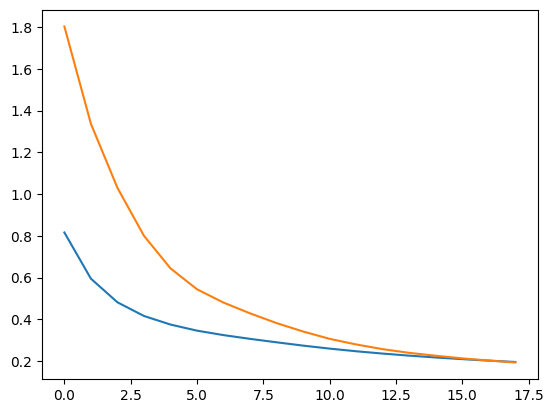

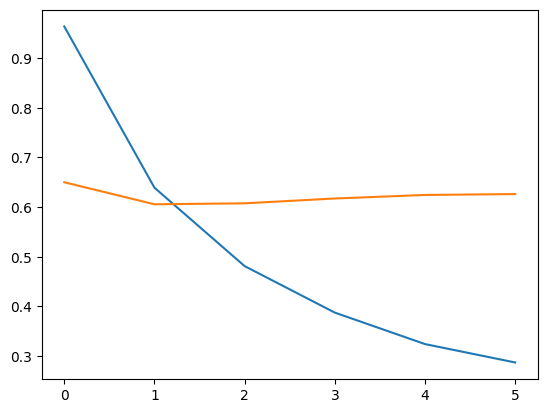

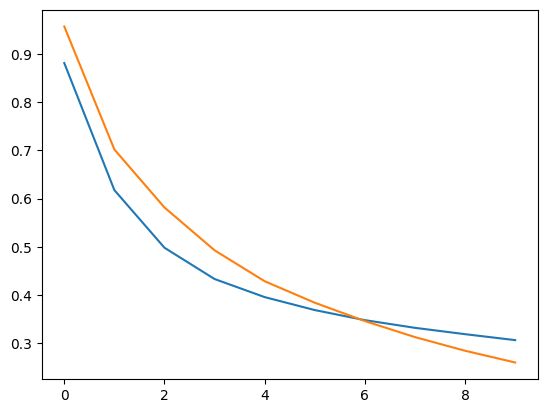

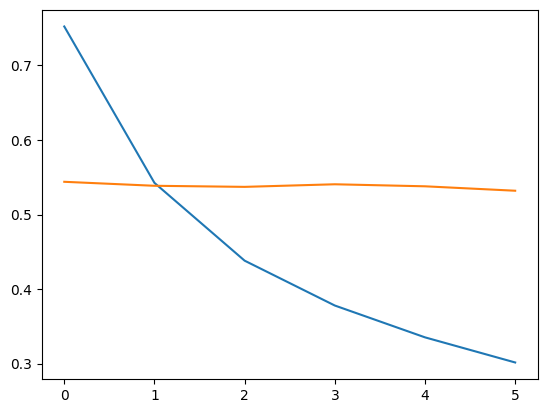

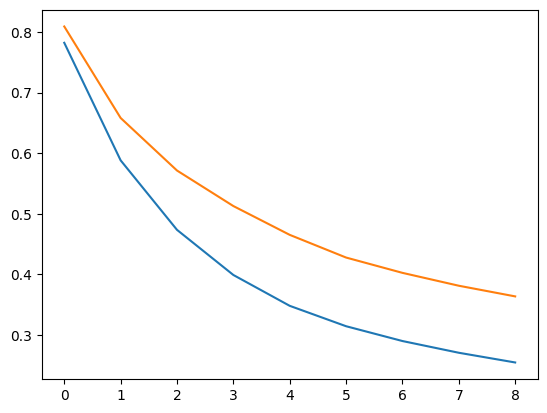

In [ ]:
for fold in random_training_per_model['GCN']['per_fold']:
    train_art = [art['loss'] for art in fold['history']['train']]
    val_art = [art['loss'] for art in fold['history']['val']]

    x_train = [x for x in range(len(train_art))]
    x_val = [x for x in range(len(val_art))]

    import matplotlib.pyplot as plt

    plt.plot(x_train, train_art)
    plt.plot(x_val, val_art)
    plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# model_names = [model().__class__.__name__ for model in model_factories]
model_names = ["Sage2L", "Sage2L+MLP", "Sage2L+drop", "GCN", "MLP"]

# formatted_transductive  = dict(zip(model_names, [np.array(res).mean() for _, res in results['transductive'].items()]))

def plot_f1(formatted, title, subset=set()):
    if subset:
        formatted = {k:formatted[k] for k in subset}

    sorted_formatted = dict(sorted(formatted.items(), key=lambda x: x[1], reverse=True))

    names = list(sorted_formatted.keys())
    values = list(sorted_formatted.values())

    plt.figure(figsize=(7, 5))
    plt.bar(names, values)
    plt.title(title)
    plt.ylabel("F1 Score")
    plt.xlabel("Modello")
    plt.ylim(0, 1)  # opzionale

    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

    plt.show()

# plot_f1(formatted_transductive  , title='Trasductive F1-scores')
# plot_f1(formatted_transductive , title='Transductive F1-scores', subset=set(['GCN', 'MLP', 'Sage2L']))


In [2]:
from graph_data_manipulation import rewire_degree_preserving_complete, rewire_degree_preserving_stratified_connected, rewire_non_degree_preserving_stratified_complete
import numpy as np


rewire_modes = {
    "Su tutto il grafo, degree preserving": rewire_degree_preserving_complete, 
    "Separatamente per classe, degree preserving ": rewire_degree_preserving_stratified_connected, 
    "Separatamente per grafo, non degree preserving": rewire_non_degree_preserving_stratified_complete
    }

def compare_rewired(data, rewire_mode, title, mode='transductive', seed=4, n=200, test_size=0.1):
    
    g_rewired = rewire_mode(
        data,
        seed=seed
    )
    
    factory = lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)

    task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
    trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=10)

    test_metrics = [] 
    test_metrics_rew = []

    for x in tqdm(range(n), desc="Training GCN on original and rewired graphs", unit="trainings"):
        splitter = StratifiedSplitterWithTestHoldout(test_size=test_size, n_splits=5, seed=x, mode=mode)
        parts = splitter.split(data, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)
        rewired_parts = splitter.split(g_rewired, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

        cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
        cv_rew = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
        artifacts, summary = cv.run(task, data, parts)
        artifacts_rew, summary_rew = cv_rew.run(task, g_rewired, rewired_parts)

        evaluator = Evaluator(model_factory=factory, mode=mode)
        test_metrics.append(evaluator.evaluate(task, data, parts, artifacts["best_state"])['f1'])
        test_metrics_rew.append(evaluator.evaluate(task, g_rewired, rewired_parts, artifacts_rew["best_state"])['f1'])


    test_metrics_mlp, _ = compare_models_over_repeats(
        data, 
        [lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)], 
        splitter_ctor, task, trainer, mode=mode, n=n)

    formatted = {
        'GCN - original': np.array(test_metrics).mean(),
        'GCN - rewired' : np.array(test_metrics_rew).mean(),
        'MLP': np.array(list(test_metrics_mlp.values())).mean()
    }
    plot_f1(formatted, title=title)

/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/libpyg.so: undefined symbol: _ZN3c1010Dispatcher17runRecordFunctionERN2at14RecordFunctionESt17reference_wrapperIKNS_14FunctionSchemaEENS_11DispatchKeyE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/to

Training Progress: 100%|██████████| 200/200 [01:28<00:00,  2.25iteration/s]


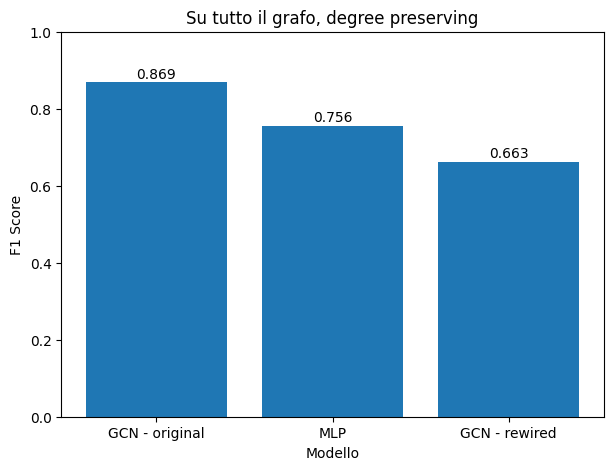

Training Progress: 100%|██████████| 200/200 [01:33<00:00,  2.14iteration/s]


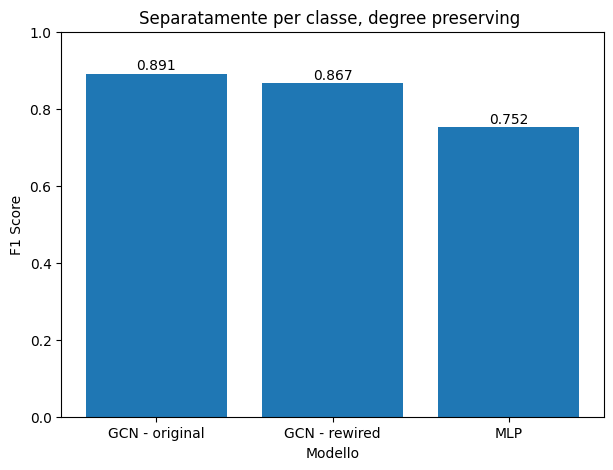

Training Progress: 100%|██████████| 200/200 [01:30<00:00,  2.21iteration/s]


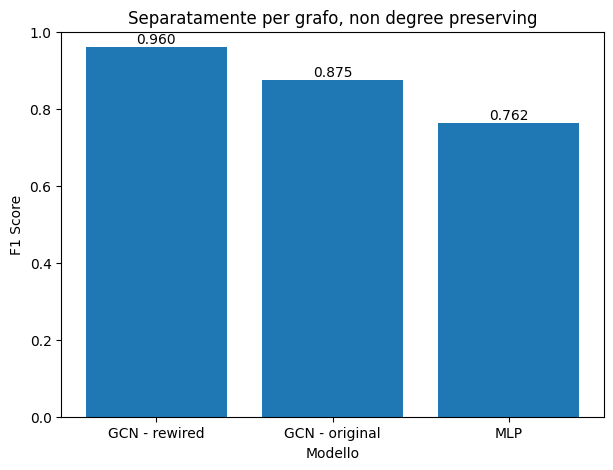

In [8]:
for title, rewire_mode in rewire_modes.items():
    compare_rewired(data, rewire_mode, title, n=200)

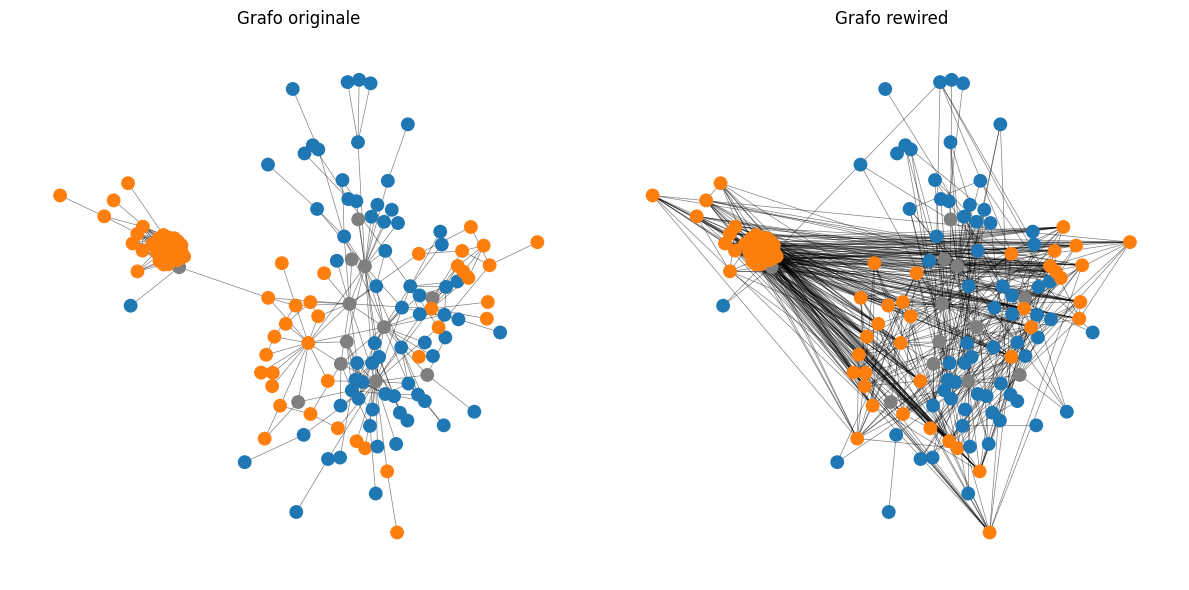

In [11]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data


def plot_graph_before_after(
    data: "Data",
    data_rewired: "Data",
    *,
    node_size: int = 80,
    alpha_edges: float = 0.5,
    seed_layout: int = 42,
):
    """
    Plotta il grafo originale e quello rewired affiancati, usando lo stesso layout.

    - Colore nodi = classe (y=0, y=1).
    - Stesso posizionamento (spring layout) per confronto visivo.

    Parametri
    ---------
    data : Data
        Grafo originale PyG.
    data_rewired : Data
        Grafo dopo rewiring (stesso numero di nodi, stessi indici).
    node_size : int
        Dimensione dei nodi nel plot.
    alpha_edges : float
        Trasparenza degli archi.
    seed_layout : int
        Seed per il layout spring di NetworkX (riproducibilità).
    """
    assert data.num_nodes == data_rewired.num_nodes, "I due grafi devono avere lo stesso numero di nodi"

    # converte a NetworkX (non orientato per la visualizzazione)
    G_real = to_networkx(data, to_undirected=True, remove_self_loops=True)
    G_rew  = to_networkx(data_rewired, to_undirected=True, remove_self_loops=True)

    # layout unico per entrambi
    pos = nx.spring_layout(G_real, seed=seed_layout)

    # colori nodi in base a y
    y = data.y.detach().cpu().numpy()
    # mappa semplice: 0 -> blu, 1 -> arancione, altro -> grigio
    def _color(c):
        if c == 0:
            return "tab:blue"
        elif c == 1:
            return "tab:orange"
        else:
            return "tab:gray"

    node_colors = [_color(int(c)) for c in y]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # --- grafo originale ---
    ax = axes[0]
    nx.draw_networkx_nodes(
        G_real, pos,
        node_color=node_colors,
        node_size=node_size,
        ax=ax
    )
    nx.draw_networkx_edges(
        G_real, pos,
        alpha=alpha_edges,
        width=0.5,
        ax=ax
    )
    ax.set_title("Grafo originale")
    ax.axis("off")

    # --- grafo rewired ---
    ax = axes[1]
    nx.draw_networkx_nodes(
        G_rew, pos,
        node_color=node_colors,  # stesse classi, stessi colori
        node_size=node_size,
        ax=ax
    )
    nx.draw_networkx_edges(
        G_rew, pos,
        alpha=alpha_edges,
        width=0.5,
        ax=ax
    )
    ax.set_title("Grafo rewired")
    ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_graph_before_after(data, rewire_non_degree_preserving_stratified_complete(data))
